In [ ]:
danawa4.to_csv('danawa4.csv', index=False, encoding='utf-8-sig')
print("저장 완료")

저장 완료


In [ ]:
danawa_scaled.to_csv('danawa_scaled.csv', index=False, encoding='utf-8-sig')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score

# 데이터 로드
danawa4 = pd.read_csv('danawa3_ver3.csv')



In [ ]:
danawa4.columns

Index(['제품명', '브랜드', 'AI여부', 'CPU브랜드', 'CPU등급', '그래픽', 'RAM(GB)', 'OS',
       '배터리용량', '무게(kg)', '화면크기(인치)', '가격', '리뷰수', '용도', '용도_게임용', '용도_그래픽작업용',
       '용도_사무', '용도_휴대용', 'has_rating', '별점', '외장그래픽', '등록일', '등록_경과월'],
      dtype='object')

In [ ]:
# OS 열 불리언 변환
danawa4['OS_프리도스'] = (danawa4['OS'] == '프리도스').astype(int)
danawa4['OS_윈도우11'] = (danawa4['OS'] == '윈도우11').astype(int)
danawa4['OS_macOS'] = (danawa4['OS'] == 'macOS').astype(int)

# 원본 OS 열 제거
danawa4.drop(columns=['OS'], inplace=True)

print("OS 원-핫 인코딩 완료")
danawa4.head()

OS 원-핫 인코딩 완료


,제품명,브랜드,AI여부,CPU브랜드,CPU등급,그래픽,RAM(GB),배터리용량,무게(kg),화면크기(인치),...,용도_휴대용,has_rating,별점,외장그래픽,등록일,등록_경과월,Cluster,OS_프리도스,OS_윈도우11,OS_macOS
0,LG전자 2026 그램 프로16 16Z90U-KU7WK,LG전자,1,인텔,7,내장,32.0,77.0,1.190,16.0,...,0,1,4.9,0,26.01.,2,4,0,1,0
1,LG전자 2025 그램 프로16 16Z90TS-GU7WK,LG전자,1,인텔,7,내장,32.0,77.0,1.199,16.0,...,0,1,4.9,0,25.03.,12,4,0,1,0
2,HP 오멘 16-ap0117AX,HP,0,AMD,9,외장,32.0,83.0,2.350,16.0,...,0,1,4.8,1,25.06.,9,3,1,0,0
3,에이서 프레데터 헬리오스 네오 16 AI PHN16-73-9797,에이서,1,인텔,9,외장,32.0,90.0,2.450,16.0,...,0,1,5.0,1,25.07.,8,5,1,0,0
4,레노버 LEGION 5 15IRX10 i7 5060,레노버,0,인텔,7,외장,16.0,80.0,1.900,15.1,...,0,1,4.6,1,25.08.,7,3,1,0,0


In [ ]:
제거할 열
- ['제품명', '브랜드'
클러스터링 고려중
- 'AI여부','CPU등급','외장그래픽','램', 'OS','배터리용량','무게(kg)','화면크기(인치)','가격','리뷰수', 'has_rating','별점'

숫자 : 'CPU등급', '램','배터리용량','무게(kg)','화면크기(인치)','가격','리뷰수','별점'
불리언 : 'AI여부','외장그래픽','OS','has_rating',
범주:

SyntaxError: invalid syntax (3243408483.py, line 1)

In [ ]:
danawa_scaled = danawa4.copy()
danawa_scaled = danawa_scaled[['CPU등급', 'RAM(GB)','배터리용량','무게(kg)','화면크기(인치)','가격','리뷰수','AI여부','외장그래픽','OS','has_rating','별점']]

In [ ]:
danawa_scaled.describe()
#로그변환 대상 : 리뷰수


,AI여부,CPU등급,RAM(GB),배터리용량,무게(kg),화면크기(인치),가격,리뷰수,용도_게임용,용도_그래픽작업용,용도_사무,용도_휴대용,has_rating,별점,외장그래픽,등록_경과월
count,863.000000,863.000000,863.000000,863.000000,863.000000,863.000000,8.630000e+02,863.000000,863.000000,863.000000,863.000000,863.000000,863.000000,863.000000,863.000000,863.000000
mean,0.543453,6.932793,28.220162,72.118969,1.967408,15.921900,2.443758e+06,7.949015,0.587486,0.455388,0.389340,0.042874,0.661645,3.134299,0.599073,17.506373
std,0.498397,1.461058,15.434096,15.817499,0.586843,1.019756,1.034557e+06,39.410207,0.492572,0.498295,0.487883,0.202690,0.473424,2.284941,0.490370,13.531681
min,0.000000,3.000000,8.000000,38.000000,0.972000,13.300000,6.260000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,5.000000,16.000000,54.600000,1.490000,15.600000,1.748935e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000
50%,1.000000,7.000000,32.000000,73.000000,1.900000,16.000000,2.270000e+06,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4.700000,1.000000,13.000000
75%,1.000000,7.000000,32.000000,86.000000,2.450000,16.000000,2.898885e+06,3.000000,1.000000,1.000000,1.000000,0.000000,1.000000,5.000000,1.000000,26.000000
max,1.000000,9.000000,128.000000,100.000000,4.340000,18.400000,7.236000e+06,523.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,62.000000


In [ ]:
danawa_scaled['리뷰수'] = np.log1p(danawa_scaled['리뷰수'])

In [ ]:
# min_max 스케일
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
features = danawa_scaled[['CPU등급', 'RAM(GB)','배터리용량','무게(kg)','화면크기(인치)','가격','리뷰수', '별점']]
features_scaled = scaler.fit_transform(features)

# 스케일 처리 하고 덮어씌우기
danawa_scaled[['CPU등급', 'RAM(GB)','배터리용량','무게(kg)','화면크기(인치)','가격','리뷰수','별점']] = features_scaled


In [ ]:
danawa_scaled

,CPU등급,RAM(GB),배터리용량,무게(kg),화면크기(인치),가격,리뷰수,AI여부,외장그래픽,OS,has_rating,별점
0,0.666667,0.200000,0.629032,0.064727,0.529412,0.389259,0.740196,1,0,1,1,0.98
1,0.666667,0.200000,0.629032,0.067399,0.529412,0.281995,0.799162,1,0,1,1,0.98
2,1.000000,0.200000,0.725806,0.409145,0.529412,0.268230,0.553500,0,1,0,1,0.96
3,1.000000,0.200000,0.838710,0.438836,0.529412,0.342965,0.332100,1,1,0,1,1.00
4,0.666667,0.066667,0.677419,0.275534,0.352941,0.203177,0.604359,0,1,0,1,0.92
...,...,...,...,...,...,...,...,...,...,...,...,...
858,0.666667,0.066667,0.403226,0.290380,0.529412,0.170802,0.175455,0,1,0,1,0.80
859,1.000000,0.200000,0.725806,0.450713,0.529412,0.381089,0.000000,1,1,1,0,0.00
860,0.333333,0.066667,0.629032,0.067399,0.529412,0.178516,0.332100,1,0,0,1,1.00
861,0.333333,0.000000,0.177419,0.245843,0.450980,0.045874,0.257037,0,0,1,1,0.90


In [ ]:
danawa_scaled.loc[danawa_scaled['OS'] == 'macOS', 'OS'] = 1

In [ ]:
danawa_scaled['OS'].value_counts()

,count
OS,
1,592
0,271


In [ ]:
def visualize_kmeans_plot_multi(cluster_lists, X_features):
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import math

    n_clusters = len(cluster_lists)
    n_cols = min(n_clusters, 5)
    n_rows = math.ceil(n_clusters / n_cols)

    fig, axs = plt.subplots(figsize=(4 * n_cols, 4 * n_rows), nrows=n_rows, ncols=n_cols)

    axs = np.array(axs).reshape(-1) if n_clusters > 1 else [axs]

    pca = PCA(n_components=2)
    pca_transformed = pca.fit_transform(X_features)
    dataframe = pd.DataFrame(pca_transformed, columns=['PCA1', 'PCA2'])

    for ind, n_cluster in enumerate(cluster_lists):

        clusterer = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(pca_transformed)
        dataframe['cluster'] = cluster_labels

        unique_labels = np.unique(cluster_labels)
        markers = ['o', 's', '^', 'x', '*', 'D', 'v', 'p', 'H', '+']

        for label in unique_labels:
            label_df = dataframe[dataframe['cluster'] == label]
            cluster_legend = f'Cluster {label}' if label != -1 else 'Noise'
            axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
                             edgecolor='k', marker=markers[label % len(markers)], label=cluster_legend)

        axs[ind].set_title(f'Number of Clusters: {n_cluster}')
        axs[ind].legend(loc='upper right')

    for ax in axs[n_clusters:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def visualize_silhouette(cluster_lists, X_features):
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import numpy as np
    import math

    n_clusters = len(cluster_lists)

    n_cols = min(n_clusters, 5)
    n_rows = math.ceil(n_clusters / n_cols)

    fig, axs = plt.subplots(figsize=(4 * n_cols, 4 * n_rows), nrows=n_rows, ncols=n_cols)

    axs = np.array(axs).reshape(-1) if n_clusters > 1 else [axs]

    for ind, n_cluster in enumerate(cluster_lists):

        clusterer = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title(f'Number of Clusters: {n_cluster}\nSilhouette Score: {round(sil_avg, 3)}')
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels == i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                                   facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

    for ax in axs[n_clusters:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
danawa_scaled.columns

Index(['CPU등급', 'RAM(GB)', '배터리용량', '무게(kg)', '화면크기(인치)', '가격', '리뷰수', 'AI여부',
       '외장그래픽', 'OS', 'has_rating', '별점'],
      dtype='object')

/tmp/ipykernel_430/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_430/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_430/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[ind].scatter(x=label_df['PCA1'], y=label_df['PCA2'], s=70,
/tmp/ipykernel_430/3892084.py:33: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is igno

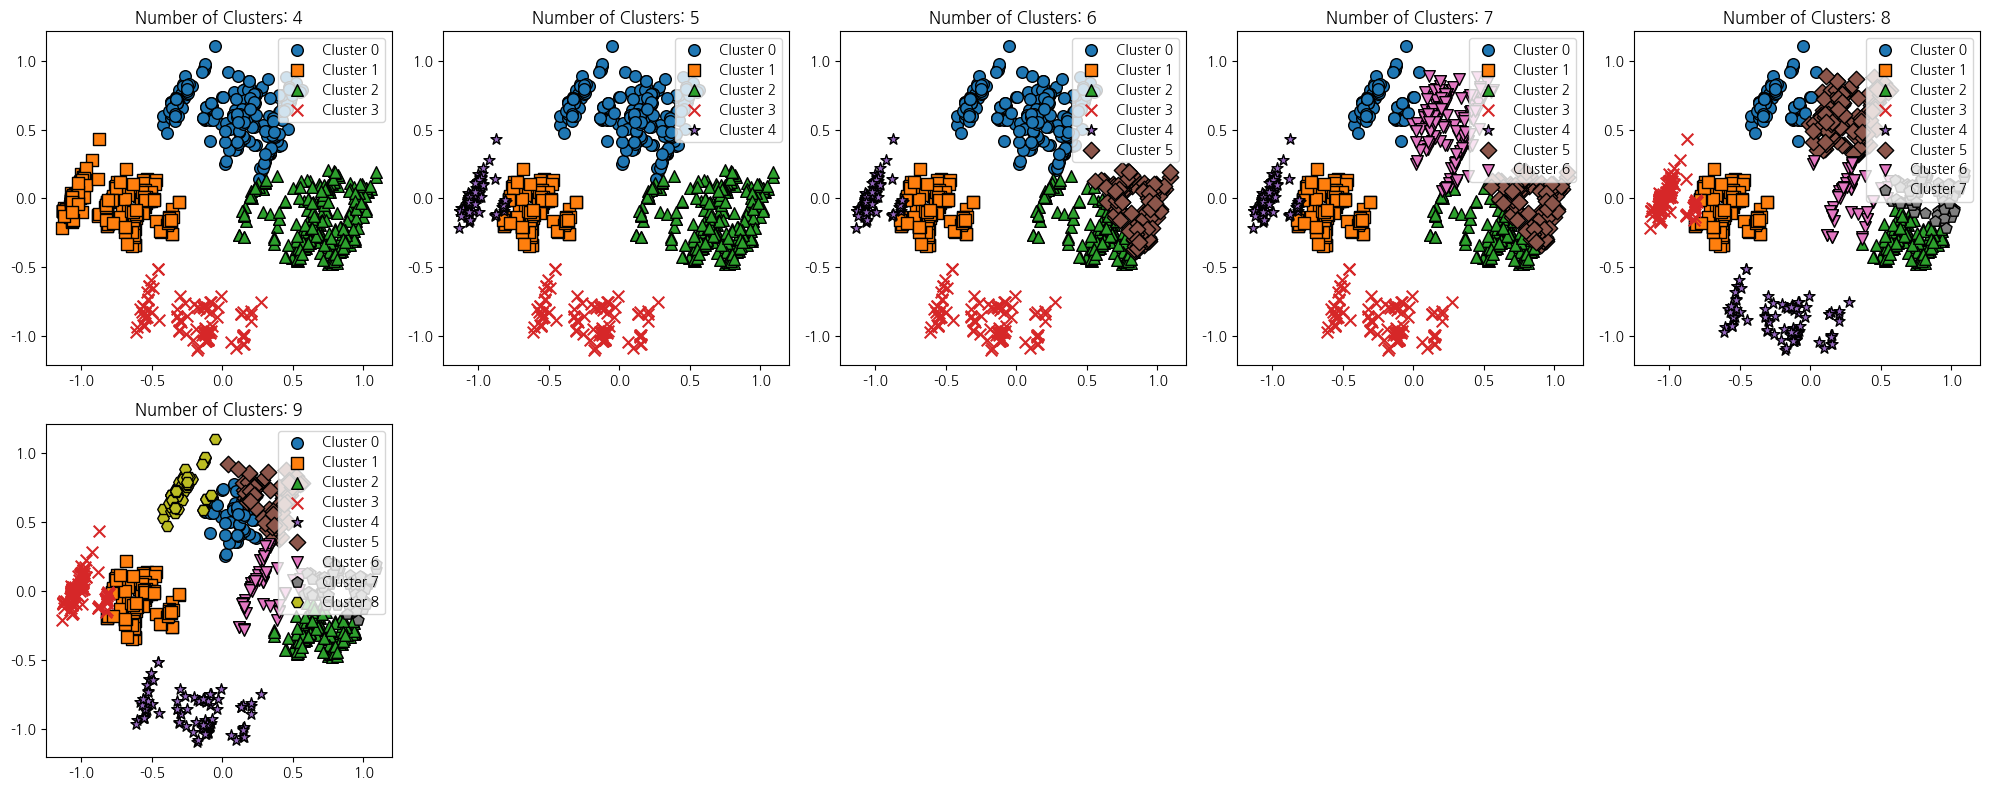

In [ ]:
visualize_kmeans_plot_multi([4,5,6,7,8,9],danawa_scaled[['CPU등급', '배터리용량', '무게(kg)', '화면크기(인치)', '가격', '리뷰수', 'AI여부',
       '외장그래픽', 'OS', '별점']])
#'has_rating'

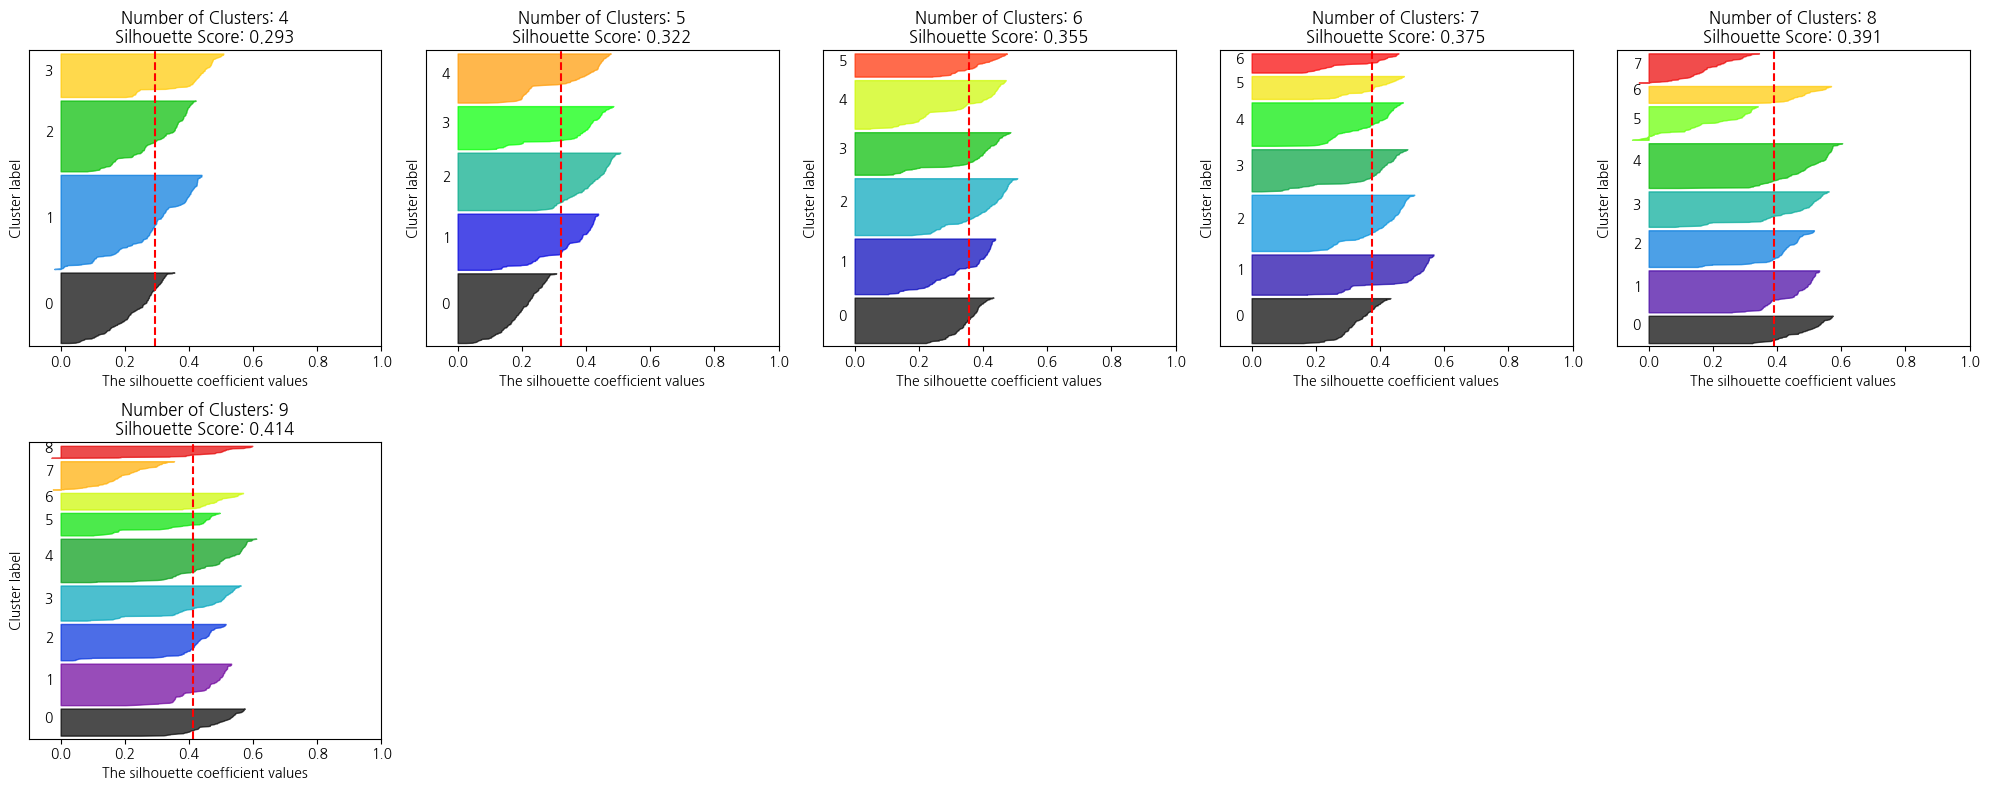

In [ ]:
visualize_silhouette([4,5,6,7,8,9],danawa_scaled[['CPU등급', '배터리용량', '무게(kg)', '화면크기(인치)', '가격', '리뷰수', 'AI여부',
       '외장그래픽', 'OS', '별점']])

In [ ]:
df = danawa_scaled[['CPU등급', '배터리용량', '무게(kg)', '화면크기(인치)', '가격', '리뷰수', 'AI여부',
       '외장그래픽', 'OS', '별점']]

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=0)
labels = kmeans.fit_predict(df)

danawa4['Cluster'] = labels # labels -> 각 데이터가 어떤 군집에 속하는지


In [ ]:
danawa4.columns

Index(['제품명', '브랜드', 'AI여부', 'CPU브랜드', 'CPU등급', '그래픽', 'RAM(GB)', 'OS',
       '배터리용량', '무게(kg)', '화면크기(인치)', '가격', '리뷰수', '용도', '용도_게임용', '용도_그래픽작업용',
       '용도_사무', '용도_휴대용', 'has_rating', '별점', '외장그래픽', '등록일', '등록_경과월',
       'Cluster'],
      dtype='object')

In [ ]:
danawa4['Cluster'].value_counts()

,count
Cluster,
2,180
1,176
4,154
0,144
3,135
5,74


In [ ]:
lap_nums =danawa4.groupby('Cluster')[['CPU등급','배터리용량','무게(kg)','화면크기(인치)','가격','리뷰수','별점']].agg({
                                                    'mean',
                                                    'median'
                                                   })
lap_nums

CPU등급             배터리용량           무게(kg)          화면크기(인치)         \
             mean median       mean median      mean median       mean median   
Cluster                                                                         
0        7.861111    7.0  81.509722   90.0  2.233882  2.225  16.218056   16.0   
1        6.034091    5.0  67.608636   72.0  1.439051  1.390  15.415909   15.6   
2        7.255556    7.0  71.084444   65.0  2.374333  2.425  16.378333   16.0   
3        7.177778    7.0  69.892593   65.0  2.291178  2.300  16.212593   16.0   
4        6.116883    5.0  67.858117   72.2  1.430662  1.399  15.320779   15.6   
5        7.729730    7.0  80.017568   82.0  2.242027  2.250  16.159459   16.0   

                   가격                   리뷰수               별점         
                 mean     median       mean median      mean median  
Cluster                                                              
0        3.095457e+06  2972500.0   6.402778    1.0  2.986111   4.65  
1        2.043864e+06  1899000.0   0.005682    0.0  0.005682   0.00  
2        2.696417e+06  2396135.0   3.205556    1.0  3.777222   5.00  
3        2.322532e+06  2115000.0   7.503704    2.0  4.412593   5.00  
4        1.977365e+06  1949500.0  25.493506    3.0  4.790909   5.00  
5        2.703865e+06  2543830.0   5.689189    1.0  3.520270   4.80

In [ ]:
 'AI여부','외장그래픽','OS'
danawa4.groupby('Cluster')['AI여부'].mean()

,AI여부
Cluster,
0,1.000000
1,0.772727
2,0.000000
3,0.000000
4,0.746753
5,1.000000


In [ ]:
danawa4.groupby('Cluster')['외장그래픽'].mean()

,외장그래픽
Cluster,
0,1.000000
1,0.000000
2,1.000000
3,0.881481
4,0.000000
5,1.000000


In [ ]:
danawa4.groupby(['Cluster','OS'])['제품명'].count()

Cluster  OS   
0        윈도우11    144
1        macOS     12
         윈도우10      1
         윈도우11    116
         프리도스      47
2        윈도우10     17
         윈도우11    163
3        프리도스     135
4        macOS      4
         윈도우10      4
         윈도우11    131
         프리도스      15
5        프리도스      74
Name: 제품명, dtype: int64

## 클러스터별 상세 분석

### Cluster 0 — 144개
CPU등급 7.86, 배터리 81.5Wh, 무게 2.23kg, 화면 16.2인치, 평균가격 약 309만원. 외장GPU 100%, AI칩 100%로 사양 조합이 가장 높은 그룹. OS는 전량 윈도우11. 리뷰 수 평균 6.4개이나 별점 평균이 2.99로 전 클러스터 중 최저. 신제품이거나 고가 제품 특성상 리뷰 축적이 적고, 남아 있는 리뷰의 평점이 낮은 패턴.

---

### Cluster 1 — 176개
CPU등급 6.03, 배터리 67.6Wh, 무게 1.44kg, 화면 15.4인치, 평균가격 약 204만원. 외장GPU 0%, AI칩 77.3%. OS 구성이 윈도우11(116), 프리도스(47), macOS(12)로 혼재. 리뷰 수 평균 0.006, 별점 평균 0.006으로 사실상 리뷰 없음. 크롤링 시점에 등록된 지 얼마 안 됐거나 소비자 노출이 거의 없는 제품군으로 볼 수 있는 데이터 패턴.

---

### Cluster 2 — 180개 (최대 클러스터)
CPU등급 7.26, 배터리 71.1Wh, 무게 2.37kg, 화면 16.4인치, 평균가격 약 270만원. 외장GPU 100%, AI칩 0%. OS는 윈도우11(163)과 윈도우10(17)으로 구성되어 AI칩 미탑재 고성능 윈도우 노트북 그룹. 무게(2.37kg)가 전 클러스터 중 최대. 별점 평균 3.78.

---

### Cluster 3 — 135개
CPU등급 7.18, 배터리 69.9Wh, 무게 2.29kg, 화면 16.2인치, 평균가격 약 232만원. 외장GPU 88.1%, AI칩 0%, OS 전량 프리도스. OS가 프리도스 단일로 구성된 점이 다른 클러스터와 명확히 구분되는 특징. 리뷰 수 평균 7.5개, 별점 평균 4.41로 리뷰 보유 클러스터 중 별점이 가장 높음.

---

### Cluster 4 — 154개
CPU등급 6.12, 배터리 67.9Wh, 무게 1.43kg, 화면 15.3인치, 평균가격 약 198만원으로 가격이 가장 낮은 그룹. 외장GPU 0%, AI칩 74.7%. OS는 윈도우11(131) 중심에 프리도스(15), macOS(4) 소수 포함. 리뷰 수 평균 25.5개, 별점 평균 4.79로 두 지표 모두 전 클러스터 최고. 경량·보급형 제품군으로 소비자 접점이 가장 넓은 그룹.

---

### Cluster 5 — 74개 (최소 클러스터)
CPU등급 7.73, 배터리 80.0Wh, 무게 2.24kg, 화면 16.2인치, 평균가격 약 270만원. 외장GPU 100%, AI칩 100%, OS 전량 프리도스. Cluster 0과 사양 구성(외장GPU+AI칩)은 동일하나 OS가 프리도스인 점이 유일한 차별점. 리뷰 수 5.7개, 별점 3.52.

---

## 주요 비교 포인트 요약

| 구분 | Cluster 0 | Cluster 5 |
|---|---|---|
| 외장GPU / AI칩 | 100% / 100% | 100% / 100% |
| OS | 윈도우11 | 프리도스 |
| 가격 | 309만원 | 270만원 |
| 별점 | 2.99 | 3.52 |

Cluster 0과 5는 하드웨어 사양이 거의 동일하며 OS 유무로 분리된 구조.

| 구분 | Cluster 1 | Cluster 4 |
|---|---|---|
| 외장GPU | 0% | 0% |
| 무게 | 1.44kg | 1.43kg |
| 가격 | 204만원 | 198만원 |
| 리뷰 수 | 0.006 | 25.5 |

Cluster 1과 4는 스펙이 매우 유사하나 리뷰 데이터의 유무로 분리된 구조. Cluster 1은 데이터 수집 시점에 리뷰가 없는 신규 또는 비노출 제품일 가능성이 수치상 나타남.